# Introduccion a tensor flow 

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
import numpy as np
import matplotlib.pyplot as plt

#version de tensorflow
print(f"Versión de TensorFlow: {tf.__version__}")

#version keras
print(f"Versión de Keras: {tf.keras.__version__}")

Versión de TensorFlow: 2.20.0
Versión de Keras: 3.13.2


In [2]:
#print gpu disponible
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [4]:
train_images.shape

(60000, 28, 28)

In [6]:
test_images.shape

(10000, 28, 28)

In [9]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

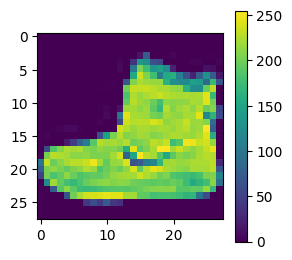

In [13]:
plt.figure(figsize=(3,3))
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

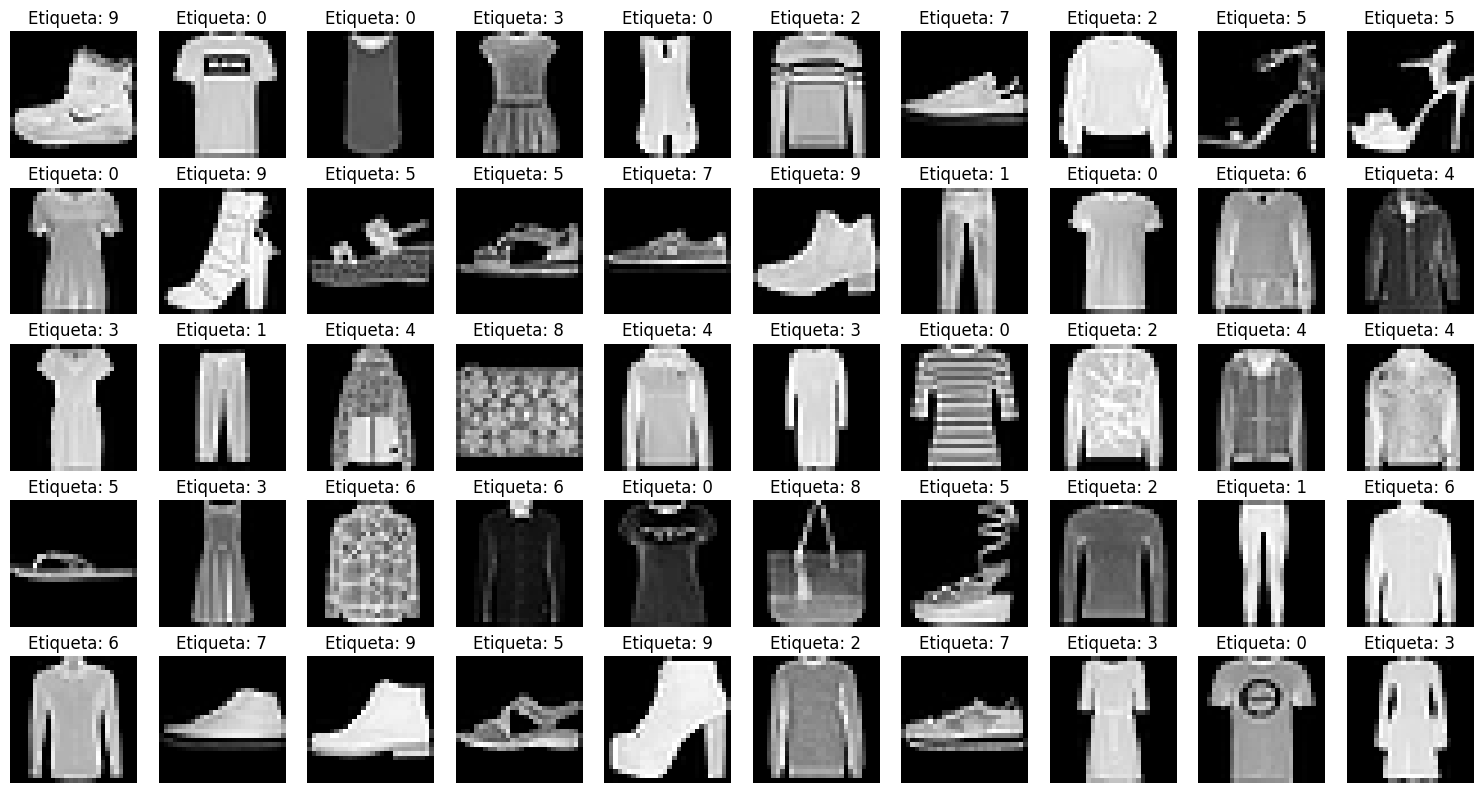

In [14]:
plt.figure(figsize=(15, 8))

for i in range(50):
    plt.subplot(5, 10, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(f"Etiqueta: {train_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

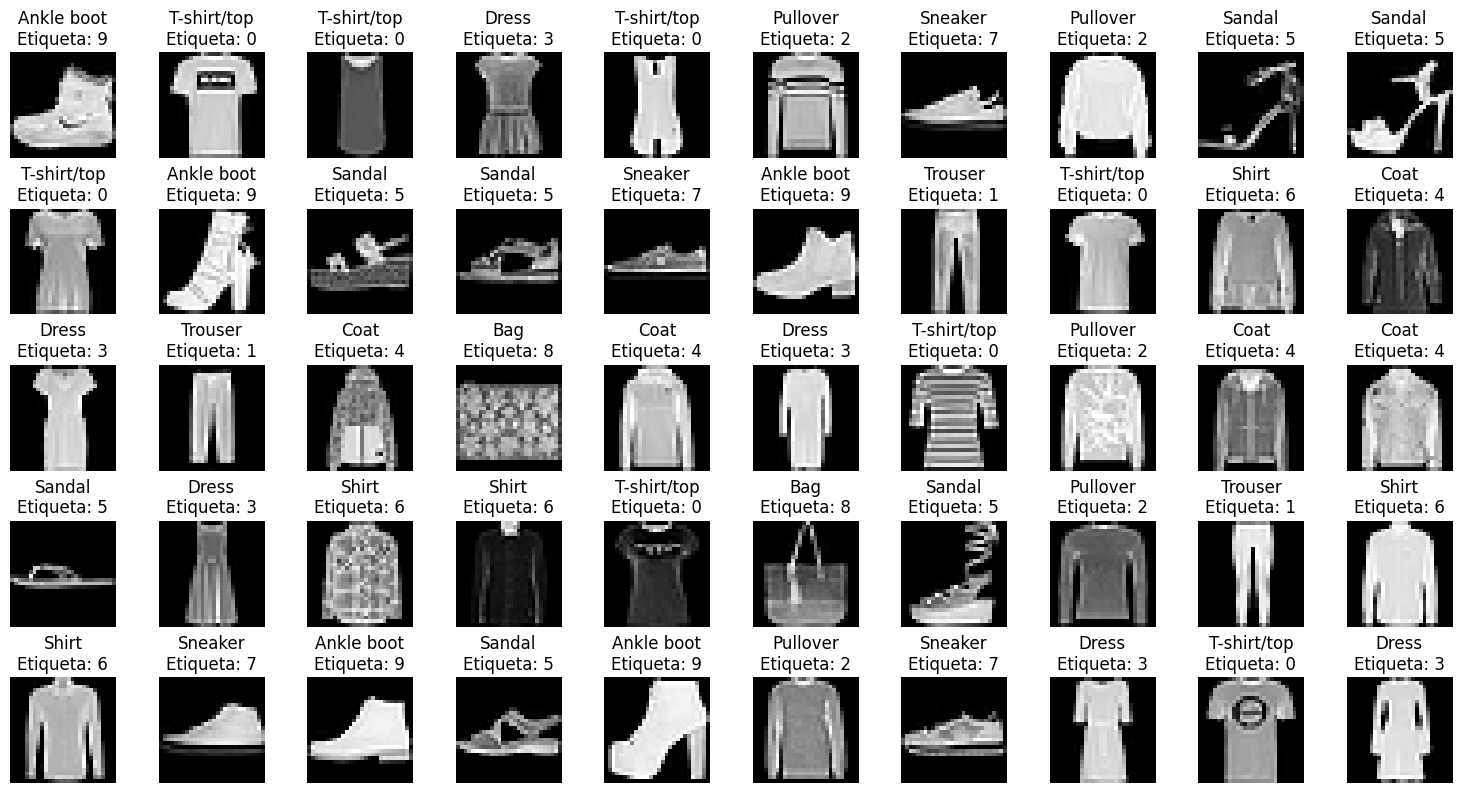

In [18]:
plt.figure(figsize=(15, 8))

for i in range(50):
    plt.subplot(5, 10, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(f"{class_names[train_labels[i]]}\nEtiqueta: {train_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [20]:
train_images[0,:, :]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [22]:
### Forma A: Lista de capas en el constructor
# Recomendada cuando ya conoces la arquitectura completa.

model_a = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),  # Capa de entrada (imagen 28x28)
    tf.keras.layers.Flatten(),  # Capa de entrada (imagen 28x28)
    tf.keras.layers.Dense(64, activation='relu'),   # Capa oculta 1 con 64 neuronas
    tf.keras.layers.Dense(32, activation='relu'),   # Capa oculta 2 con 32 neuronas
    tf.keras.layers.Dense(16, activation='relu'),   # Capa de salida (clasificación binaria: 0 o 1)
    tf.keras.layers.Dense(10, activation='softmax') # Capa de salida (clasificación multiclase: 10 clases)
], name="Modelo_Lista")


In [23]:
model_a.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

In [24]:
model_a.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8040 - loss: 0.5574
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8621 - loss: 0.3859
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8727 - loss: 0.3507
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8826 - loss: 0.3265
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8864 - loss: 0.3098
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8889 - loss: 0.3000
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8946 - loss: 0.2865
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8978 - loss: 0.2761
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9006 - loss: 0.2698
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9024 - loss: 0.2602


In [33]:
from google.colab import drive
import os

drive.mount("/content/drive")

ruta = "/content/drive/MyDrive/modelo_reconocimiento_de_prendas.keras"
model_a.save(ruta)

print("Guardado:", os.path.exists(ruta))
print(ruta)

Mounted at /content/drive
Guardado: True
/content/drive/MyDrive/modelo_reconocimiento_de_prendas.keras


In [35]:
test_loss, test_acc = model_a.evaluate(test_images, test_labels, verbose=2)

print(f'\nPrecisión en el conjunto de prueba: {test_acc:.4f}')

313/313 - 1s - 2ms/step - accuracy: 0.8729 - loss: 0.3647

Precisión en el conjunto de prueba: 0.8729


In [36]:
predictions = model_a.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [37]:
predictions[0]

array([2.9917555e-10, 1.4063559e-07, 8.1791168e-10, 2.4947911e-07,
       1.1655765e-07, 1.4146765e-04, 5.6397283e-07, 3.1898113e-03,
       7.4168011e-06, 9.9666023e-01], dtype=float32)

In [38]:
np.argmax(predictions[0])

np.int64(9)